In [18]:
import utils
import numpy as np
import os
import h5py
import matplotlib.pyplot as plt
utils.default_plt_params()

In [19]:
data_pth = r'C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id' # these are data with both off and on food time points, but without neuron ID labels

# data_pth = r'C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf702_with_id' # these are data with only on-food time points, but with neuron ID labels

nsm_idx = 75

uid = '2022-04-05-01-data.h5'

path_h5 = os.path.join(data_pth,uid)


In [20]:
# run this cell if this is a SWF415 dataset (without neuron ID labels, both off-food and on-food time points were recorded)

with h5py.File(path_h5, 'r') as h5f:
    data = utils.h5_to_dict(h5f)
     


In [21]:
data.keys()

dict_keys(['behavior', 'gcamp', 'timing'])

In [22]:
data['behavior'].keys()

dict_keys(['angular_velocity', 'body_angle', 'body_angle_absolute', 'body_angle_all', 'head_angle', 'nose_angle', 'nose_curling', 'pumping', 'reversal_events', 'reversal_vec', 'stage_x', 'stage_y', 'velocity', 'worm_curvature'])

In [23]:
data['gcamp'].keys()

dict_keys(['idx_nsm', 'idx_splits', 'match_org_to_skip', 'match_skip_to_org', 'trace_array', 'trace_array_original', 'traces_array_F_F20'])

In [24]:
data['gcamp']['idx_nsm']

array([ 60, 110])

In [25]:
data['timing'].keys()

dict_keys(['time_food_encounter', 'timestamp_confocal', 'timestamp_nir'])

In [26]:
data['gcamp']['trace_array'].shape

(1600, 128)

In [27]:
trace_array = data['gcamp']['trace_array']

In [28]:
trace_array.shape

(1600, 128)

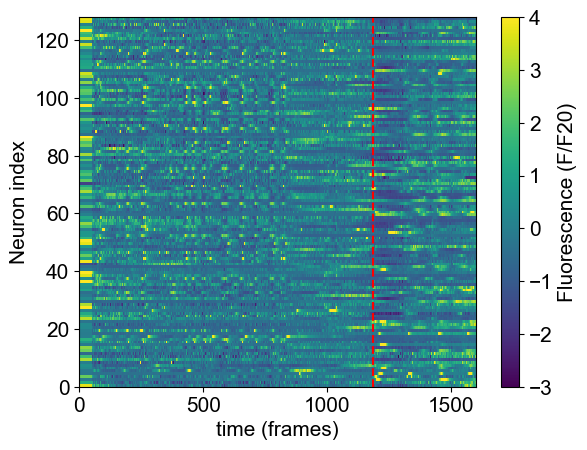

In [30]:
plt.figure()
plt.pcolormesh(trace_array.T, cmap='viridis', vmin=-3, vmax=4)
plt.axvline(data['timing']['time_food_encounter'], color='red', linestyle='--')
plt.xlabel('time (frames)')
plt.ylabel('Neuron index')
plt.colorbar(label='Fluorescence (F/F20)')
plt.show()

In [ ]:
plt.figure()
plt.plot(data['gcamp']['traces_array_F_F20'][:,nsm_idx])
plt.axvline(data['timing']['time_food_encounter'], color='red', linestyle='--')
plt.xlabel('time (frames)')
plt.ylabel('NSM activity (F/F20)')
plt.show()

plt.figure()
plt.plot(data['behavior']['velocity'])
plt.axvline(data['timing']['time_food_encounter'], color='red', linestyle='--')
plt.xlabel('time (frames)')
plt.ylabel('Velocity')
plt.show()

## CURATE NSM OVER ALL DATASETS

Processing swf415_no_id dataset...
  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-01-16-01-data.h5...


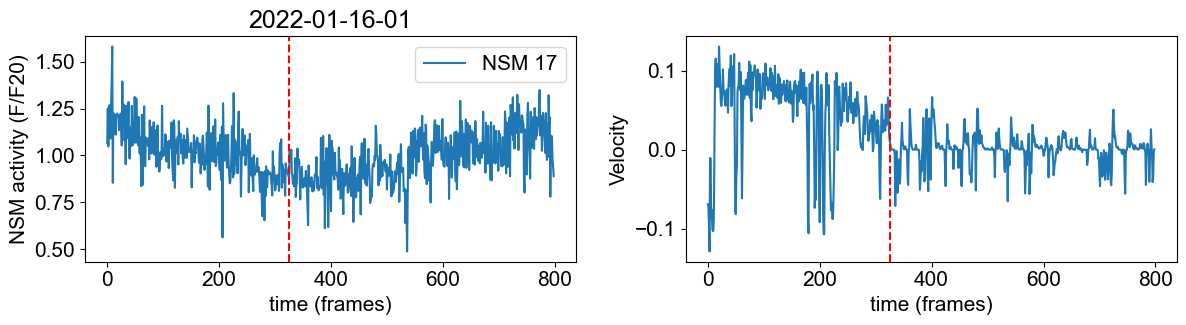

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-01-25-01-data.h5...


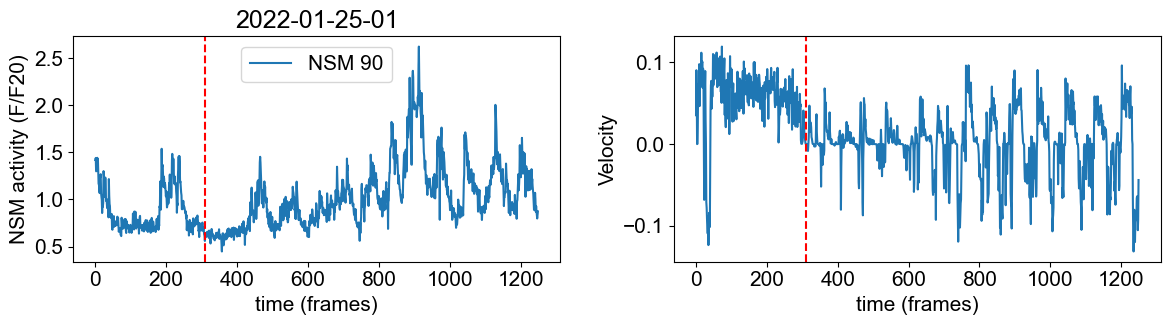

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-03-17-01-data.h5...


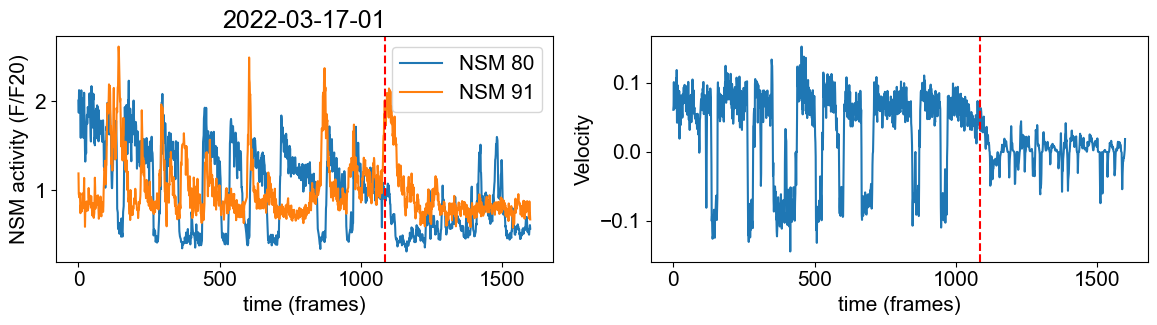

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-03-25-03-data.h5...


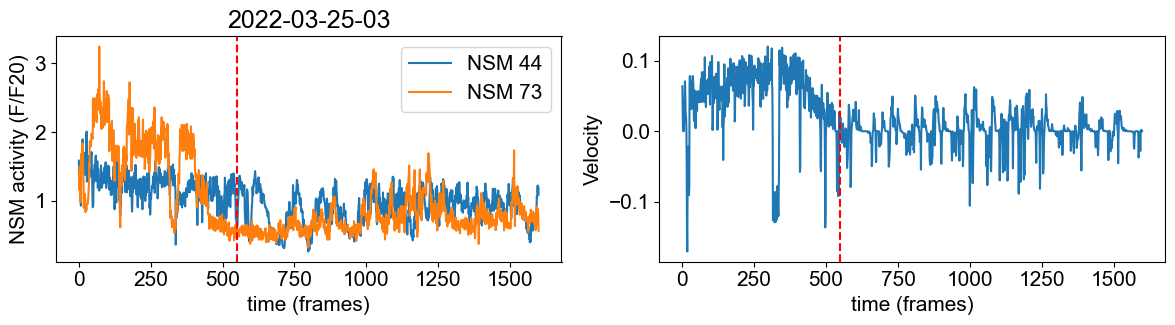

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-04-05-01-data.h5...


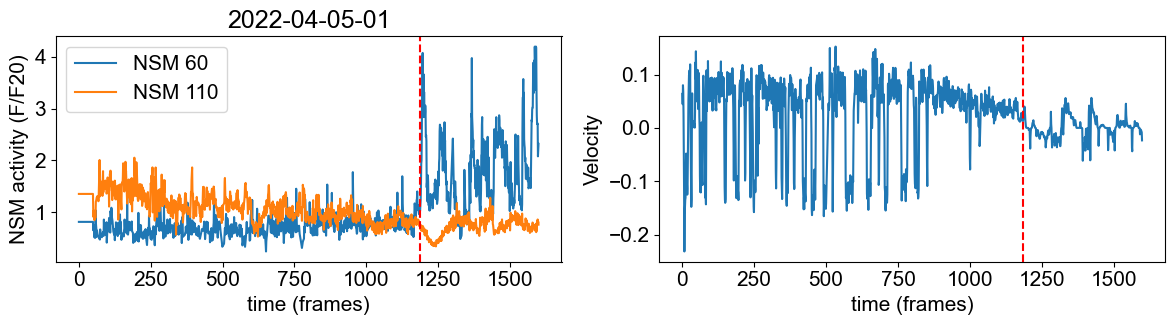

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-04-12-02-data.h5...


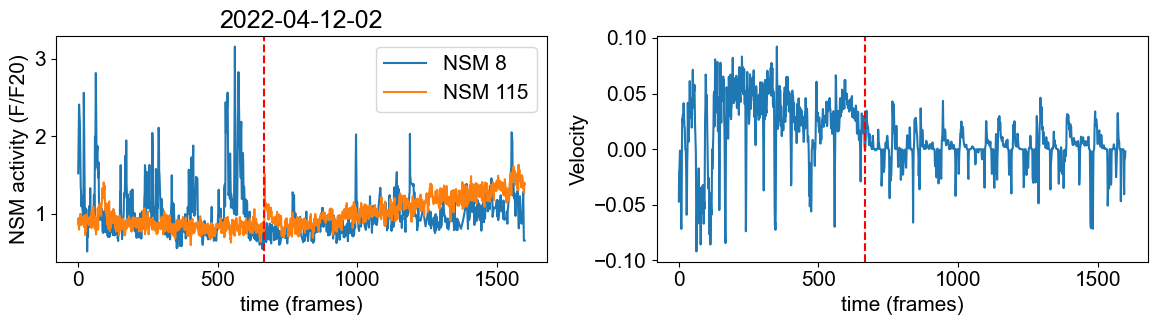

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-05-02-01-data.h5...


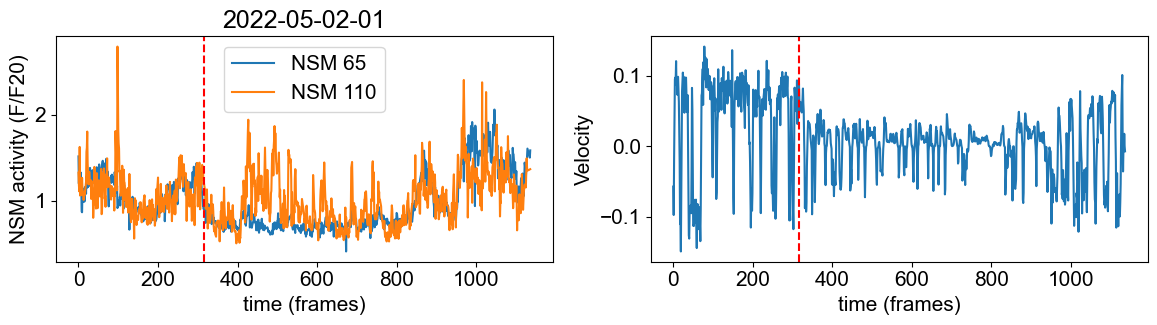

Processing swf702_with_id dataset...
  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf702_with_id\2022-07-26-31-data.h5...


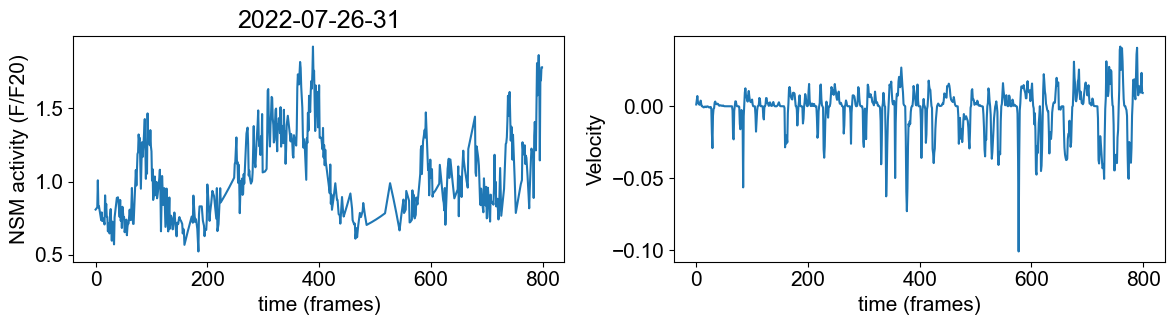

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf702_with_id\2022-07-26-38-data.h5...


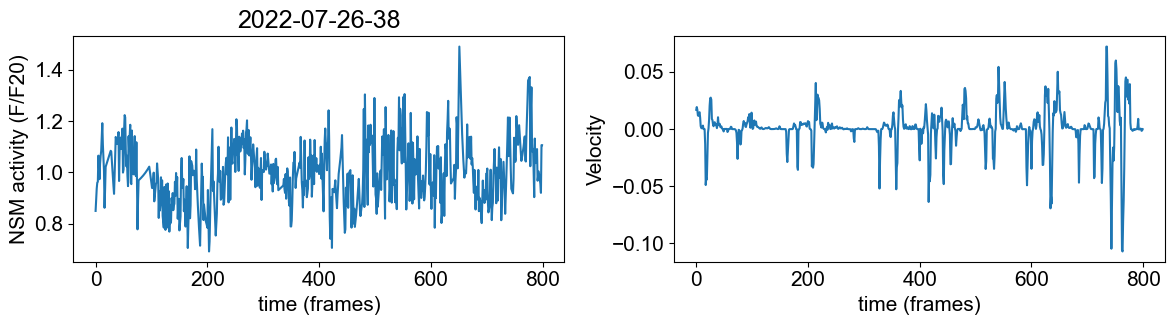

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf702_with_id\2022-07-27-31-data.h5...


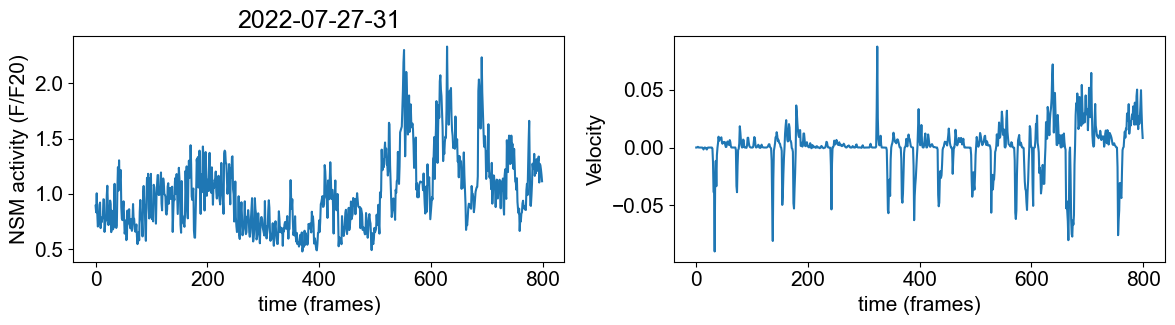

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf702_with_id\2022-07-27-38-data.h5...


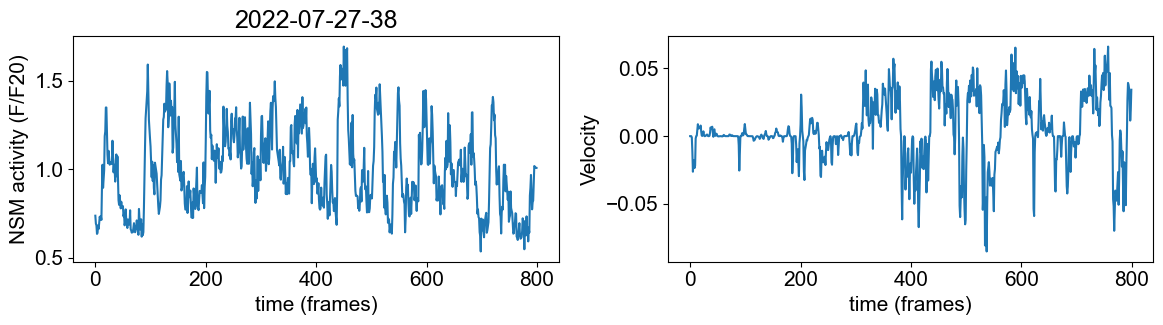

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf702_with_id\2022-07-27-45-data.h5...


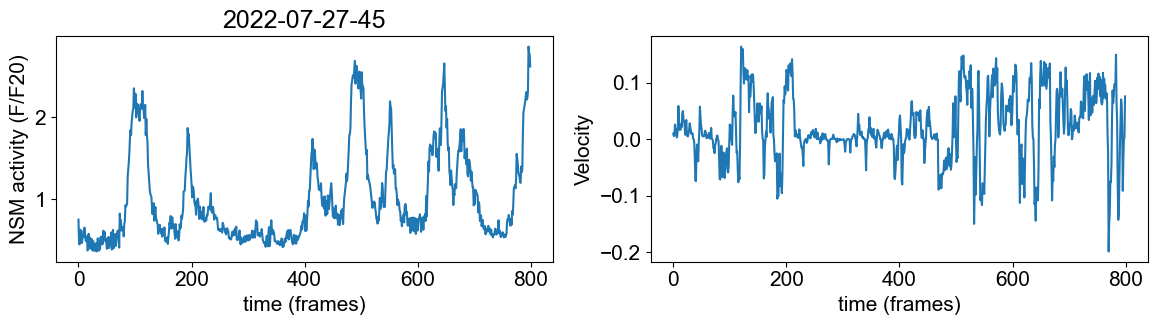

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf702_with_id\2022-08-02-31-data.h5...


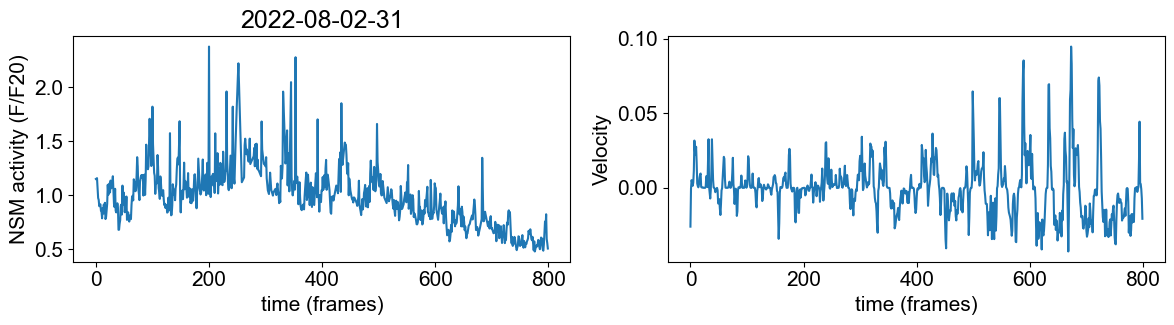

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf702_with_id\2022-08-02-38-data.h5...


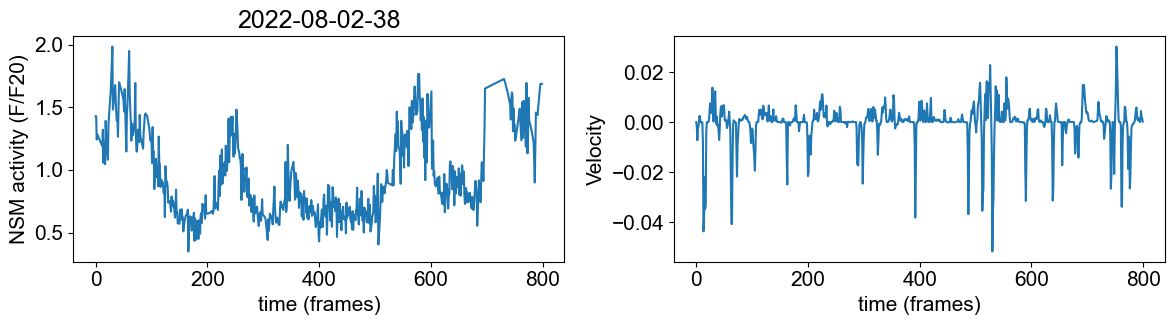

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf702_with_id\2022-08-03-31-data.h5...


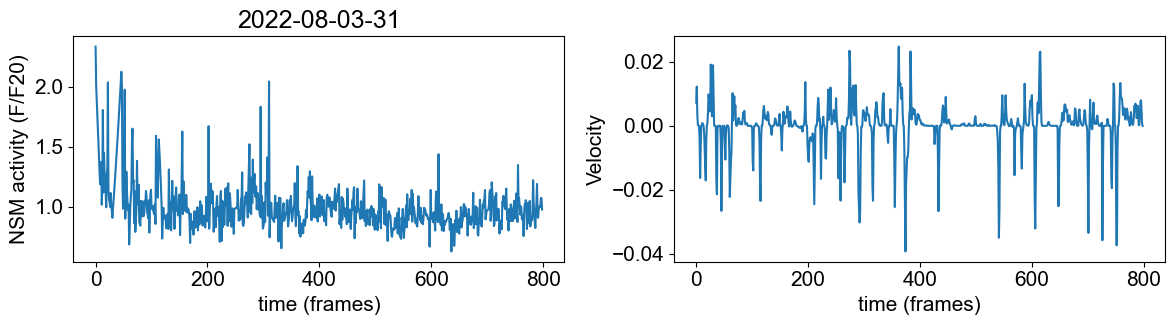

In [9]:
import utils
import numpy as np
import os
import h5py
import matplotlib.pyplot as plt
utils.default_plt_params()
import glob

data_pth = r'C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024'

swf_pth = ['swf415_no_id', 'swf702_with_id']

plt.close('all')

for swf in swf_pth:
    print(f'Processing {swf} dataset...')
    swf_dir = os.path.join(data_pth, swf)
    h5_files = glob.glob(os.path.join(swf_dir, '*.h5'))

    for h5_file in h5_files:
        print(f'  Loading {h5_file}...')
        with h5py.File(h5_file, 'r') as h5f:
            data = utils.h5_to_dict(h5f)

        plt.figure(figsize=(12, 3.5))
        
        plt.subplot(1, 2, 1)

        if '702' in swf:
            nsm_idx = 75
            plt.plot(data['gcamp']['traces_array_F_F20'][:, nsm_idx], label=f'NSM {nsm_idx}')
        else:
            nsm_idx = data['gcamp']['idx_nsm']
            # if nsm_idx is a list, plot all traces
            if isinstance(nsm_idx, (list, np.ndarray)):
                for idx in nsm_idx:
                    plt.plot(data['gcamp']['traces_array_F_F20'][:, idx], label=f'NSM {idx}')
                plt.legend()
            else:
                plt.plot(data['gcamp']['traces_array_F_F20'][:, nsm_idx])


        try:
            plt.axvline(data['timing']['time_food_encounter'], color='red', linestyle='--')
        except:
            pass
        plt.xlabel('time (frames)')
        plt.ylabel('NSM activity (F/F20)')
        plt.title(f'{os.path.basename(h5_file)[:-8]}')
        
        plt.subplot(1, 2, 2)
        plt.plot(data['behavior']['velocity'])
        try:            
            plt.axvline(data['timing']['time_food_encounter'], color='red', linestyle='--')
        except:
            pass
        plt.xlabel('time (frames)')
        plt.ylabel('Velocity')
        
        plt.tight_layout()
        plt.show()
